In [1]:
%matplotlib inline
from secsy import cubedsphere as cs
from secsy import CSplot
from secsy import get_SECS_J_G_matrices, get_SECS_B_G_matrices
import lompe
import os
import gc
import glob
import apexpy
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')
from my_utils import load_folder_to_dataframe, mjd2000_to_datetime, add_qd_gridlines, load_cdf_file, mjd2000_to_datetime, load_and_combine_dtu
from IPython.display import clear_output


RE = 6371.2e3
RI = RE + 110e3

theta0=0.25 # for j_G matrix singularity limit

Epoch = 2025.

# make cubed sphere projection and grid
location = (-40,71)
orientation = 0
L, W, Lres, Wres = 2500e3,3500e3,100.0e3,100.0e3

projection = cs.CSprojection(location, orientation)
grid = cs.CSgrid(projection, L, W, Lres, Wres, R = RI, wshift=1.0)

shp = grid.shape

# make lompe model, used to compute gradient matrices in magnetic east/west (conductances don't matter for us)
model = lompe.Emodel(grid, Hall_Pedersen_conductance = (0,0), epoch=Epoch, ew_regularization_limit=(70,90))

# Define meridian
meridian_lat_qd = np.arange(60, 86+0.2, 0.2)
meridian_lon_qd = np.ones(len(meridian_lat_qd))*50
meridian_lat_plot = np.arange(55, 90+0.5, 0.5)
meridian_lon_plot = np.ones(len(meridian_lat_plot))*50

apex_obj = apexpy.Apex(date=datetime(2025, 2, 12), refh=110)
meridian_lat_geo, meridian_lon_geo = apex_obj.convert(meridian_lat_qd, meridian_lon_qd, 'qd', 'geo')
meridian_lat_plot, meridian_lon_plot = apex_obj.convert(meridian_lat_plot, meridian_lon_plot, 'qd', 'geo')

In [2]:
grid.size

736

In [2]:
stations_all = ['ATU', 'DMH', 'GDH', 'HOV', 'KUV', 'NRD', 'PIF', 'SKT', 'SUM', 'UMQ',
            'FHB', 'KUL', 'NAQ', 'SCO', 'STF', 'SVS', 'THL', 'UPN']
stations_all.sort()

stations = np.load('stations_dtu.npy',allow_pickle=True)
bad_stations = [s for s in stations_all if s not in stations]

# Read CSV
df = pd.read_csv("dtu_stations.csv")
iaga_column = "IAGA"
lat_column = "lat_gd"
lon_column = "lon_gd"

# Filter stations based on IAGA list (and sort by station name so it matches df_mag)
filtered_df = df[df[iaga_column].isin(stations)].sort_values('IAGA')

# Extract latitude and longitude vectors
lat_mag = filtered_df[lat_column].to_numpy()
lon_mag = filtered_df[lon_column].to_numpy()

In [3]:
# Filter stations based on IAGA list (and sort by station name so it matches df_mag)
filtered_df_bad = df[df[iaga_column].isin(bad_stations)].sort_values('IAGA')

# Extract latitude and longitude vectors
lat_mag_bad = filtered_df_bad[lat_column].to_numpy()
lon_mag_bad = filtered_df_bad[lon_column].to_numpy()

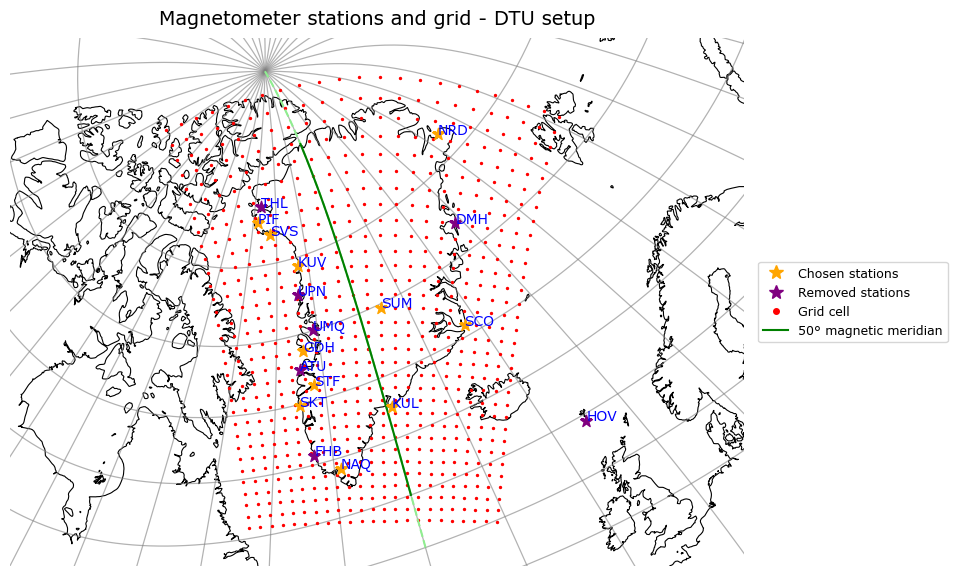

In [6]:
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import matplotlib.patches as mpatches
import cartopy.crs as ccrs
import cartopy.feature as cfeature

lon = grid.lon.flatten()
lat = grid.lat.flatten()

fig = plt.figure(figsize=(10, 6))  # wider figure to accommodate legend

ax = fig.add_subplot(
    1, 1, 1,
    projection=ccrs.LambertConformal(central_longitude=-42, central_latitude=72)
)

ax.add_feature(cfeature.LAND, facecolor='white')
ax.add_feature(cfeature.OCEAN, facecolor='white')
ax.add_feature(cfeature.COASTLINE, linewidth=0.8, edgecolor='black', zorder=0)

ax.scatter(lon, lat, transform=ccrs.PlateCarree(), s=2, color='red', zorder=5)
ax.scatter(lon_mag, lat_mag, transform=ccrs.PlateCarree(), marker='*', s=80, color='orange', zorder=7)
ax.scatter(lon_mag_bad, lat_mag_bad, transform=ccrs.PlateCarree(), marker='*', s=80, color='purple', zorder=7)

for i, txt in enumerate(stations):
    ax.annotate(txt, (lon_mag[i], lat_mag[i]), transform=ccrs.PlateCarree(), color='blue', size=10, zorder=8)
for i, txt in enumerate(bad_stations):
    ax.annotate(txt, (lon_mag_bad[i], lat_mag_bad[i]), transform=ccrs.PlateCarree(), color='blue', size=10, zorder=8)

ax.plot(meridian_lon_plot, meridian_lat_plot, transform=ccrs.PlateCarree(), color='lightgreen', linestyle='--', zorder=6)
ax.plot(meridian_lon_geo, meridian_lat_geo, transform=ccrs.PlateCarree(), color='green', zorder=6)

ax.set_extent([-90, 10, 53, 85], crs=ccrs.PlateCarree())

# ── Remove the black frame ──────────────────────────────────────────────────
ax.spines['geo'].set_visible(False)

# ── Title ───────────────────────────────────────────────────────────────────
ax.set_title('Magnetometer stations and grid - DTU setup', fontsize=14, pad=10)

# ── Legend handles (in requested order) ─────────────────────────────────────
chosen   = mlines.Line2D([], [], color='orange', marker='*', linestyle='None',
                         markersize=10, label='Chosen stations')
removed  = mlines.Line2D([], [], color='purple', marker='*', linestyle='None',
                         markersize=10, label='Removed stations')
grid_dot = mlines.Line2D([], [], color='red',    marker='o', linestyle='None',
                         markersize=4,  label='Grid cell')
meridian = mlines.Line2D([], [], color='green',  linestyle='-',
                         linewidth=1.5,           label='50° magnetic meridian')

ax.legend(
    handles=[chosen, removed, grid_dot, meridian],
    loc='center left',
    bbox_to_anchor=(1.02, 0.5),
    borderaxespad=0,
    frameon=True,
    fontsize=9,
)

# Instead of tight_layout(), manually set the axes position
# to leave room on the right for the legend
ax.set_position([0.05, 0.05, 0.80, 0.88])  # [left, bottom, width, height]

EXTENT = [-90, 10, 53, 85]   # same as ax.set_extent

add_qd_gridlines(
    ax, apex_obj,
    qlat_lines=range(50, 85, 5),   # adjust to your region
    qlon_lines=range(-180, 180, 10),
    extent=EXTENT,
    lat_color='grey',
    lon_color='grey',
    linewidth=0.9,
    alpha=0.6,
    linestyle='-',
    label_gridlines=False
)

plt.show()

**INTRODUCTION FIGURES**

In [27]:
df_sup = pd.read_csv('supermag_downloads/no_baseline/2025/supermag_TAB_2025_1.csv')
df_sup['time'] = pd.to_datetime(df_sup['time'])
df_sup = df_sup[df_sup['time'] < datetime(2025,1,1,0,11)]

x,y,z,t_mjd = load_cdf_file('dtu_downloads/PIF4/2025/PIF4_20250101.cdf')
df_dtu = pd.DataFrame({'X':x, 'Y':y, 'Z':z, 'time':mjd2000_to_datetime(t_mjd), 't_mjd':t_mjd})
df_dtu = df_dtu[df_dtu['time'] < datetime(2025,1,1,0,10)]

In [28]:
df_sup['dbn_geo'] = df_sup['dbn_geo'] - (df_sup['dbn_geo'].mean() - df_dtu['X'].mean())
df_sup['dbe_geo'] = df_sup['dbe_geo'] - (df_sup['dbe_geo'].mean() - df_dtu['Y'].mean())
df_sup['dbz_geo'] = df_sup['dbz_geo'] - (df_sup['dbz_geo'].mean() - df_dtu['Z'].mean())

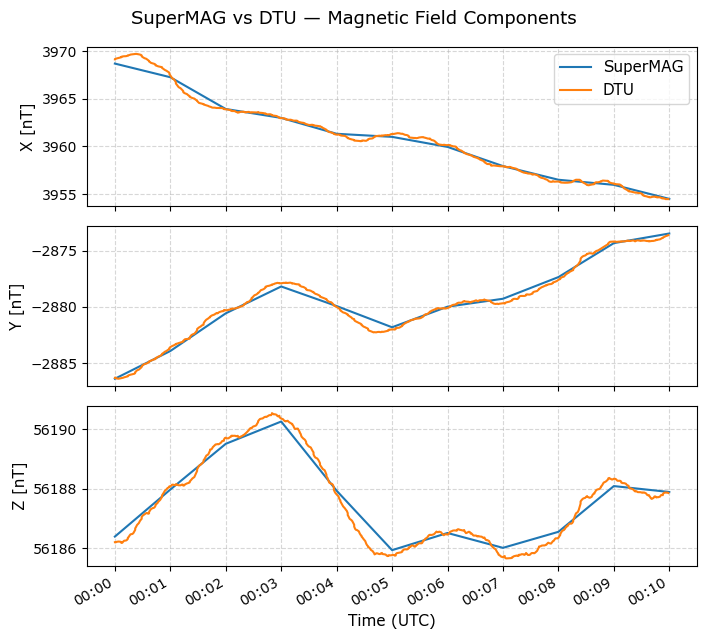

In [29]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Settings
FONTSIZE = 11
TITLE = 'SuperMAG vs DTU — Magnetic Field Components'
DPI = 100
FIG_W = 717 / DPI
FIG_H = 647 / DPI

fig, axes = plt.subplots(3, 1, figsize=(FIG_W, FIG_H), sharex=True)
fig.suptitle(TITLE, fontsize=FONTSIZE + 2)

axes[0].plot(df_sup['time'], df_sup['dbn_geo'], label='SuperMAG')
axes[0].plot(df_dtu['time'], df_dtu['X'], label='DTU')
axes[0].set_ylabel('X [nT]', fontsize=FONTSIZE)
axes[0].legend(fontsize=FONTSIZE)

axes[1].plot(df_sup['time'], df_sup['dbe_geo'], label='SuperMAG')
axes[1].plot(df_dtu['time'], df_dtu['Y'], label='DTU')
axes[1].set_ylabel('Y [nT]', fontsize=FONTSIZE)

axes[2].plot(df_sup['time'], df_sup['dbz_geo'], label='SuperMAG')
axes[2].plot(df_dtu['time'], df_dtu['Z'], label='DTU')
axes[2].set_ylabel('Z [nT]', fontsize=FONTSIZE)

axes[2].set_xlabel('Time (UTC)', fontsize=FONTSIZE)

for ax in axes:
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.tick_params(labelsize=FONTSIZE - 1)

axes[2].xaxis.set_major_locator(mdates.MinuteLocator(interval=1))
axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

In [3]:
folders = ['ATU1','DMH2','FHB1','GDH6','HOV1m','KUL2','KUV1','NAQ4m','NRD2','PIF4','SCO2','SKT1','STF2','SUM1','SVS1','THL4','UMQ1m','UPN2']
df = load_and_combine_dtu('20230325',folders,base_dir='dtu_downloads/yearly_BASELINE_rotated')

[WARNING] File not found, skipping: dtu_downloads/yearly_BASELINE_rotated/ATU1/dtu_ATU_2023_3.parquet
[WARNING] File not found, skipping: dtu_downloads/yearly_BASELINE_rotated/DMH2/dtu_DMH_2023_3.parquet
[WARNING] File not found, skipping: dtu_downloads/yearly_BASELINE_rotated/FHB1/dtu_FHB_2023_3.parquet
[WARNING] File not found, skipping: dtu_downloads/yearly_BASELINE_rotated/HOV1m/dtu_HOV_2023_3.parquet
[WARNING] File not found, skipping: dtu_downloads/yearly_BASELINE_rotated/THL4/dtu_THL_2023_3.parquet
[WARNING] File not found, skipping: dtu_downloads/yearly_BASELINE_rotated/UMQ1m/dtu_UMQ_2023_3.parquet
[WARNING] File not found, skipping: dtu_downloads/yearly_BASELINE_rotated/UPN2/dtu_UPN_2023_3.parquet


In [4]:
df_plot = df[df['time']==datetime(2023,3,25,12,33)]

In [5]:
df_plot

,time,X,Y,Z,t_mjd,iaga
20800980,2023-03-25 12:33:00,-41.292410,152.861621,-22.677374,8484.522917,GDH
20800982,2023-03-25 12:33:00,7.413824,42.333918,-5.741371,8484.522917,KUL
20800984,2023-03-25 12:33:00,-173.420549,107.847474,157.612452,8484.522928,KUV
20800986,2023-03-25 12:33:00,-39.120794,43.524306,-1.396760,8484.522917,NAQ
20800988,2023-03-25 12:33:00,-119.715264,120.662442,7.175121,8484.522917,NRD
20800990,2023-03-25 12:33:00,58.114118,120.768372,134.854546,8484.522917,PIF
20800992,2023-03-25 12:33:00,86.583891,13.516263,-24.162971,8484.522928,SCO
20800994,2023-03-25 12:33:00,-88.048302,63.962708,17.010597,8484.522917,SKT
20800996,2023-03-25 12:33:00,-76.905562,84.285626,2.593274,8484.522928,STF
20800998,2023-03-25 12:33:00,-112.378540,181.221778,-145.158591,8484.522928,SUM


In [6]:
stations = df_plot['iaga'].unique()

# Read CSV
df_loc = pd.read_csv("dtu_stations.csv")
iaga_column = "IAGA"
lat_column = "lat_gd"
lon_column = "lon_gd"

# Filter stations based on IAGA list (and sort by station name so it matches df_mag)
filtered_df = df_loc[df_loc[iaga_column].isin(stations)].sort_values('IAGA')

# Extract latitude and longitude vectors
lat_mag = filtered_df[lat_column].to_numpy()
lon_mag = filtered_df[lon_column].to_numpy()
names = stations

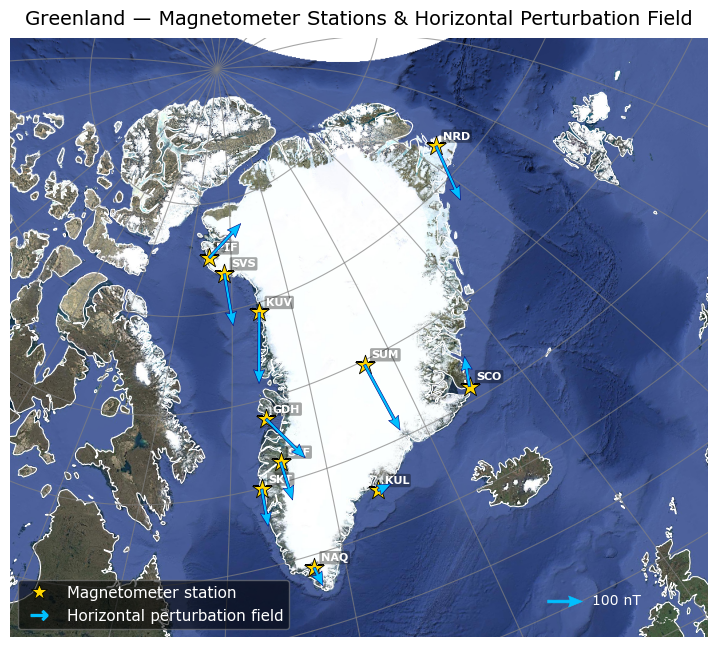

In [7]:
"""
Greenland map — magnetometer stations, QD gridlines, satellite/topo background,
and quiver plot of horizontal magnetic field (X=northward, Y=eastward).
"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.io.img_tiles as cimgt

# ── Optional: apexpy for QD gridlines ───────────────────────────────────────
try:
    import apexpy
    HAS_APEX = True
except ImportError:
    HAS_APEX = False
    print("apexpy not found — QD gridlines will be skipped.")

# ─────────────────────────────────────────────────────────────────────────────
# DATA  — assumed in scope: lon_mag, lat_mag, names (same order), df_plot
# ─────────────────────────────────────────────────────────────────────────────
# Build a lookup from IAGA code → (lon, lat) using your existing arrays
coord_lookup = {name: (lon, lat) for name, lon, lat in zip(names, lon_mag, lat_mag)}

# Build quiver arrays aligned to df_plot rows
lons_q, lats_q, U, V = [], [], [], []
for _, row in df_plot.iterrows():
    code = row['iaga']
    if code in coord_lookup:
        lon, lat = coord_lookup[code]
        lons_q.append(lon)
        lats_q.append(lat)
        U.append(row['Y'])   # eastward  → U
        V.append(row['X'])   # northward → V

lons_q = np.array(lons_q)
lats_q = np.array(lats_q)
U      = np.array(U)
V      = np.array(V)

# ─────────────────────────────────────────────────────────────────────────────
# BACKGROUND TILE
# ─────────────────────────────────────────────────────────────────────────────
tile      = cimgt.GoogleTiles(style='satellite')
TILE_ZOOM = 5

# ─────────────────────────────────────────────────────────────────────────────
# MAP PROJECTION & EXTENT
# ─────────────────────────────────────────────────────────────────────────────
PROJ   = ccrs.LambertConformal(central_longitude=-42, central_latitude=72)
EXTENT = [-80, 0, 57, 85]

fig = plt.figure(figsize=(9, 10))
ax  = fig.add_subplot(1, 1, 1, projection=PROJ)
ax.set_extent(EXTENT, crs=ccrs.PlateCarree())

# ── Tile background ──────────────────────────────────────────────────────────
ax.add_image(tile, TILE_ZOOM)

# ── Coastline & borders ──────────────────────────────────────────────────────
ax.add_feature(cfeature.COASTLINE, linewidth=0.8, edgecolor='white', zorder=3)
ax.add_feature(cfeature.BORDERS,   linewidth=0.5, edgecolor='white', zorder=3,
               linestyle='--')

# ── NO geographic gridlines ──────────────────────────────────────────────────

# ─────────────────────────────────────────────────────────────────────────────
# QD GRIDLINES
# ─────────────────────────────────────────────────────────────────────────────
if HAS_APEX:
    apex_obj = apexpy.Apex(date=2024)
    add_qd_gridlines(
        ax, apex_obj,
        qlat_lines=range(50, 86, 5),
        qlon_lines=range(-180, 180, 15),
        extent=EXTENT,
        lat_color='grey',
        lon_color='grey',
        linewidth=0.8,
        alpha=0.7,
        linestyle='-',
        label_gridlines=False,
    )

# ─────────────────────────────────────────────────────────────────────────────
# MAGNETOMETER STATIONS — stars
# ─────────────────────────────────────────────────────────────────────────────


ax.scatter(
    lon_mag, lat_mag,
    transform=ccrs.PlateCarree(),
    marker='*', s=220,
    color='gold', edgecolors='black', linewidths=0.6,
    zorder=8,
)

for lon_s, lat_s, name in zip(lon_mag, lat_mag, names):
    ax.annotate(
        name,
        xy=(lon_s, lat_s),
        xycoords=ccrs.PlateCarree()._as_mpl_transform(ax),
        xytext=(5, 5), textcoords='offset points',
        color='white', fontsize=8, fontweight='bold', zorder=9,
        bbox=dict(boxstyle='round,pad=0.15', fc='black', alpha=0.35, lw=0),
    )

# ─────────────────────────────────────────────────────────────────────────────
# QUIVER — horizontal magnetic field  (Y=east, X=north)
# ─────────────────────────────────────────────────────────────────────────────
# Scale: tune QUIVER_SCALE so arrows fit nicely (larger = shorter arrows)
QUIVER_SCALE = 2000   # nT per axis-unit; adjust to taste

qv = ax.quiver(
    lons_q, lats_q, U, V,
    transform=ccrs.PlateCarree(),
    scale=QUIVER_SCALE,
    scale_units='width',
    width=0.004,          # shaft width as fraction of axes width
    headwidth=4,
    headlength=5,
    color='deepskyblue',
    edgecolors='navy',
    linewidths=0.4,
    zorder=10,
)

# Reference arrow (quiverkey) — place in lower-right corner of axes
ref_nT = 100   # nT shown by the key arrow
ax.quiverkey(
    qv, X=0.82, Y=0.06,       # axes-fraction position
    U=ref_nT,
    label=f'{ref_nT} nT',
    labelpos='E',
    color='deepskyblue',
    labelcolor='white',
    fontproperties={'size': 10},
    zorder=11,
)

# ─────────────────────────────────────────────────────────────────────────────
# LEGEND & TITLE
# ─────────────────────────────────────────────────────────────────────────────
star_handle = mlines.Line2D(
    [], [], color='gold', marker='*', linestyle='None',
    markersize=12, markeredgecolor='black', markeredgewidth=0.6,
    label='Magnetometer station',
)
qv_handle = mlines.Line2D(
    [], [], color='deepskyblue', marker=r'$\rightarrow$', linestyle='None',
    markersize=12, label='Horizontal perturbation field',
)

ax.legend(
    handles=[star_handle, qv_handle],
    loc='lower left',
    fontsize=11,
    framealpha=0.6,
    facecolor='black',
    labelcolor='white',
    edgecolor='grey',
)

ax.set_title('Greenland — Magnetometer Stations & Horizontal Perturbation Field', fontsize=14,
             color='black', pad=10)
ax.spines['geo'].set_visible(False)

# plt.savefig('greenland_map.png', dpi=180, bbox_inches='tight',
#             facecolor=fig.get_facecolor())
plt.show()

**COVERAGE**

In [2]:
def compute_coverage(combined_df):
    # 1. Create the Month-Year period
    combined_df['year_month'] = combined_df['time'].dt.to_period('M')

    # 2. Calculate actual counts
    actual = combined_df.groupby(['iaga', 'year_month']).size().reset_index(name='actual_count')

    # 3. Ensure we account for missing months (reindexing)
    all_stations = combined_df['iaga'].unique()
    all_months = combined_df['year_month'].unique()
    full_index = pd.MultiIndex.from_product([all_stations, all_months], names=['iaga', 'year_month'])
    actual = actual.set_index(['iaga', 'year_month']).reindex(full_index, fill_value=0).reset_index()

    # 4. Calculate coverage percentage per specific month-year
    actual['expected_count'] = actual['year_month'].apply(lambda p: p.days_in_month * 24 * 60)
    actual['coverage_pct'] = (actual['actual_count'] / actual['expected_count'] * 100).round(2)

    # 5. Extract the month number from the period
    actual['month_num'] = actual['year_month'].dt.month

    # 6. AVERAGE the coverage across years for each station/month
    # This collapses multiple years into a single 1-12 month set
    monthly_avg = actual.groupby(['iaga', 'month_num'])['coverage_pct'].mean().reset_index()

    # 7. Pivot to get the 12-column format
    coverage = monthly_avg.pivot(index='iaga', columns='month_num', values='coverage_pct')
    
    # Optional: ensure column names are clean
    coverage.columns.name = 'month'
    
    return coverage

In [3]:
def compute_concurrent_coverage(combined_df):
    # Determine the "all stations" threshold
    total_stations = combined_df['iaga'].nunique()

    # 1. Count unique stations per minute
    per_minute = combined_df.groupby('time')['iaga'].nunique().reset_index(name='station_count')
    
    # 2. Identify and extract the specific timestamps with full concurrency
    per_minute['is_concurrent'] = per_minute['station_count'] == total_stations
    concurrent_times = per_minute.loc[per_minute['is_concurrent'], 'time']

    # 3. Calculate coverage per specific month-year
    per_minute['year_month'] = per_minute['time'].dt.to_period('M')
    
    actual_concurrent_minutes = per_minute.groupby('year_month')['is_concurrent'].sum()
    expected_minutes = per_minute.groupby('year_month')['year_month'].first().apply(
        lambda p: p.days_in_month * 24 * 60
    )
    
    monthly_coverage = (actual_concurrent_minutes / expected_minutes * 100)

    # 4. Collapse multiple years into a 1-12 month average
    df_coverage = monthly_coverage.reset_index(name='coverage_pct')
    df_coverage['month'] = df_coverage['year_month'].dt.month
    
    final_avg_coverage = df_coverage.groupby('month')['coverage_pct'].mean().round(2)
    final_avg_coverage.name = 'concurrent_coverage_pct'
    
    # Return both the monthly stats and the list of timestamps
    return final_avg_coverage, concurrent_times

In [4]:
def read_fn(year, folders):

    dfs = []

    for folder in folders:
        folder_path = 'dtu_downloads/' + folder +'/' + str(year)
        if not os.listdir(folder_path):
            continue
        df = (load_folder_to_dataframe(folder_path, minute=True))[['time_mjd','X']]
        df['iaga'] = folder[0:3]
        df['time'] = mjd2000_to_datetime(df['time_mjd'].values)

        dfs.append(df)
    clear_output()

    combined_df = pd.concat(dfs, ignore_index=True)

    # Sorting and formatting
    print('sorting...')
    combined_df = combined_df.sort_values(
        by=["time", 'iaga'],
        ascending=[True, True]
    ).reset_index(drop=True)

    print('removing nans...')
    ## REMOVE NANS
    combined_df = combined_df.dropna(subset=['X'])
    
    return combined_df

In [5]:
folders = ['ATU1','DMH2','FHB1','GDH6','HOV1m','KUL2','KUV1','NAQ4m','NRD2','PIF4','SCO2','SKT1','STF2','SUM1','SVS1','THL4','UMQ1m','UPN2']

combined_df = pd.concat([
    read_fn(2023, folders),
    read_fn(2024, folders),
    read_fn(2025, folders)
], ignore_index=True)


sorting...
removing nans...


In [39]:
bad_stations = coverage_mean.index.values[(coverage_mean.mean(axis=1) < 75)] # inspection of plots
bad_stations

<StringArray>
['ATU', 'DMH', 'FHB', 'HOV', 'SVS', 'THL', 'UMQ', 'UPN']
Length: 8, dtype: str

In [40]:
combined_df_filtered = combined_df[~combined_df['iaga'].isin(bad_stations)]
combined_df_bad = combined_df[combined_df['iaga'].isin(bad_stations)]

In [41]:
coverage_mean = compute_coverage(combined_df_filtered)
concurrent_mean, concurrent_times = compute_concurrent_coverage(combined_df_filtered)

In [43]:
np.save('concurrent_times_dtu_nosvs',concurrent_times)

In [ ]:
stations_all = coverage_mean.index.values
np.save('stations_dtu',stations_all)

In [8]:
np.save('concurrent_times_dtu_minute.npy',times_dtu)

In [2]:
times_dtu = np.load('concurrent_times_dtu.npy')
times_supermag = np.load('concurrent_times_supermag.npy')

In [12]:
import numpy as np

def fill_seconds(datetimes: np.ndarray) -> np.ndarray:
    # Find where consecutive entries are exactly 60 seconds apart
    diffs = np.diff(datetimes).astype("timedelta64[s]").astype(int)
    consecutive = np.where(diffs == 60)[0]
    
    # Generate all seconds to insert for each consecutive pair
    inserts = np.concatenate([
        datetimes[i] + np.arange(1, 60, dtype="timedelta64[s]")
        for i in consecutive
    ]) if len(consecutive) else np.array([], dtype="datetime64[s]")
    
    # Merge original and inserted, then sort
    result = np.concatenate([datetimes, inserts])
    result.sort()
    return result

In [13]:
times_dtu_sec = fill_seconds(times_dtu)

In [22]:
np.save('concurrent_times_dtu.npy',times_dtu_sec)

In [46]:
common = np.intersect1d(concurrent_times, times_supermag)

In [47]:
common.size/60/24

24.830555555555552

In [48]:
coverage_mean_bad = compute_coverage(combined_df_bad)
concurrent_mean_bad, _ = compute_concurrent_coverage(combined_df_bad)

In [49]:
concurrent_times.size/60/24

324.93819444444443

In [22]:
coverage_mean.shape[0]

11

In [127]:
coverage_mean

month,1,2,3,4,5,6,7,8,9,10,11,12
iaga,,,,,,,,,,,,
GDH,58.570000,49.130000,64.076667,96.736667,85.050000,87.190000,82.136667,69.270000,68.390000,85.000000,96.683333,99.920000
KUL,99.010000,97.986667,94.330000,92.830000,73.090000,66.650000,78.616667,99.993333,99.990000,100.000000,99.956667,98.893333
KUV,98.013333,75.736667,58.753333,79.146667,99.980000,99.573333,99.993333,97.853333,99.963333,99.343333,99.823333,99.996667
NAQ,87.000000,81.920000,95.586667,99.626667,99.873333,98.933333,68.803333,86.216667,98.863333,99.986667,76.300000,68.336667
NRD,66.656667,68.630000,68.816667,74.806667,99.936667,99.866667,98.830000,96.410000,93.776667,91.373333,99.946667,87.383333
PIF,99.916667,97.773333,98.790000,98.516667,99.913333,97.606667,99.823333,99.996667,99.986667,99.843333,99.833333,95.300000
SCO,100.000000,99.996667,100.000000,98.890000,99.980000,100.000000,76.780000,99.993333,100.000000,100.000000,100.000000,98.923333
SKT,99.303333,96.046667,98.863333,70.940000,99.993333,88.146667,96.666667,99.923333,55.610000,87.256667,99.920000,99.993333
STF,66.666667,71.046667,75.436667,98.890000,73.116667,66.666667,78.616667,100.000000,99.996667,100.000000,100.000000,98.923333


In [23]:
concurrent_mean

month
1     16.24
2      9.17
3      4.48
4     14.30
5     29.43
6     25.55
7     15.81
8     23.70
9      5.11
10    16.24
11    27.28
12    20.50
Name: concurrent_coverage_pct, dtype: float64

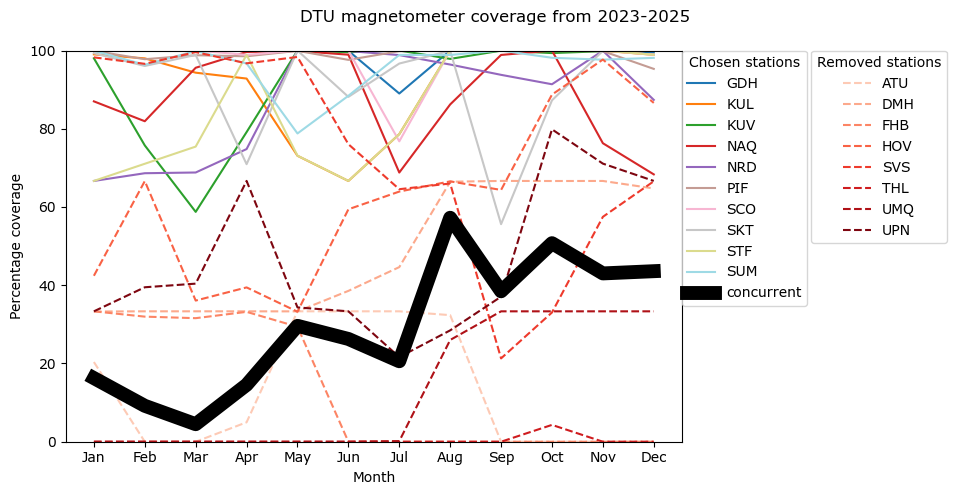

In [52]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

fig, ax = plt.subplots(figsize=(10, 5))

# --- Group 1: use tab20 or another large colormap ---
g1_stations = coverage_mean.index.values
g1_colors = cm.tab20(np.linspace(0, 1, len(g1_stations)))

group1_lines = []
for sta, color in zip(g1_stations, g1_colors):
    line, = ax.plot(coverage_mean.loc[sta].values, label=sta, color=color)
    group1_lines.append(line)

# --- Group 2: use a warm/muted colormap to signal exclusion ---
g2_stations = coverage_mean_bad.index.values
g2_colors = cm.Reds(np.linspace(0.2, 0.95, len(g2_stations)))

group2_lines = []
for sta, color in zip(g2_stations, g2_colors):
    line, = ax.plot(coverage_mean_bad.loc[sta].values, label=sta, color=color, linestyle='--')
    group2_lines.append(line)

# --- Concurrent mean ---
concurrent_line, = ax.plot(concurrent_mean.values, color='black', lw=10, label='concurrent')
group1_lines.append(concurrent_line)

ax.set_ylabel('Percentage coverage')
ax.set_xlabel('Month')
ax.set_xticks(range(0, 12))
ax.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
ax.set_ylim(0, 100)

legend1 = ax.legend(
    handles=group1_lines,
    labels=[l.get_label() for l in group1_lines],
    title='Chosen stations',
    loc='upper left',
    bbox_to_anchor=(1, 1),
    borderaxespad=0
)

legend2 = ax.legend(
    handles=group2_lines,
    labels=[l.get_label() for l in group2_lines],
    title='Removed stations',
    loc='upper left',
    bbox_to_anchor=(1.21, 1),
    borderaxespad=0
)

ax.add_artist(legend1)
fig.suptitle('DTU magnetometer coverage from 2023-2025')
fig.tight_layout()
plt.show()